In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
carbon = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-18/food_consumption.csv')

In [3]:
carbon.head()

,country,food_category,consumption,co2_emmission
0,Argentina,Pork,10.51,37.20
1,Argentina,Poultry,38.66,41.53
2,Argentina,Beef,55.48,1712.00
3,Argentina,Lamb & Goat,1.56,54.63
4,Argentina,Fish,4.36,6.96


In [88]:
carbon['food_category'].unique()

array(['Pork', 'Poultry', 'Beef', 'Lamb & Goat', 'Fish', 'Eggs',
       'Milk - inc. cheese', 'Wheat and Wheat Products', 'Rice',
       'Soybeans', 'Nuts inc. Peanut Butter'], dtype=object)

In [4]:
carbon.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1430 entries, 0 to 1429
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   country        1430 non-null   object 
 1   food_category  1430 non-null   object 
 2   consumption    1430 non-null   float64
 3   co2_emmission  1430 non-null   float64
dtypes: float64(2), object(2)
memory usage: 44.8+ KB


In [89]:
east_africa = ["Kenya", "Uganda", "Tanzania", "Rwanda", "Ethiopia"]
carbon_ea = carbon[carbon["country"].isin(east_africa)]

The average C02 emission per person by food category among five countries (Kenya, Uganda, Tanzania, Rwanda and Ethiopia) located in East Africa. Use this image

In [91]:
avg_by_food_ea = carbon_ea.groupby("food_category")["co2_emmission"].mean()

In [92]:
avg_by_food_ea

food_category
Beef                        166.138
Eggs                          0.718
Fish                          8.428
Lamb & Goat                  55.262
Milk - inc. cheese           63.754
Nuts inc. Peanut Butter       4.650
Pork                          3.370
Poultry                       1.250
Rice                         12.680
Soybeans                      0.236
Wheat and Wheat Products      3.940
Name: co2_emmission, dtype: float64

In [93]:
avg_by_food_ea_sorted = avg_by_food_ea.sort_values()

In [95]:
median_value_ea = avg_by_food_ea_sorted.median()
print(median_value_ea)

4.65


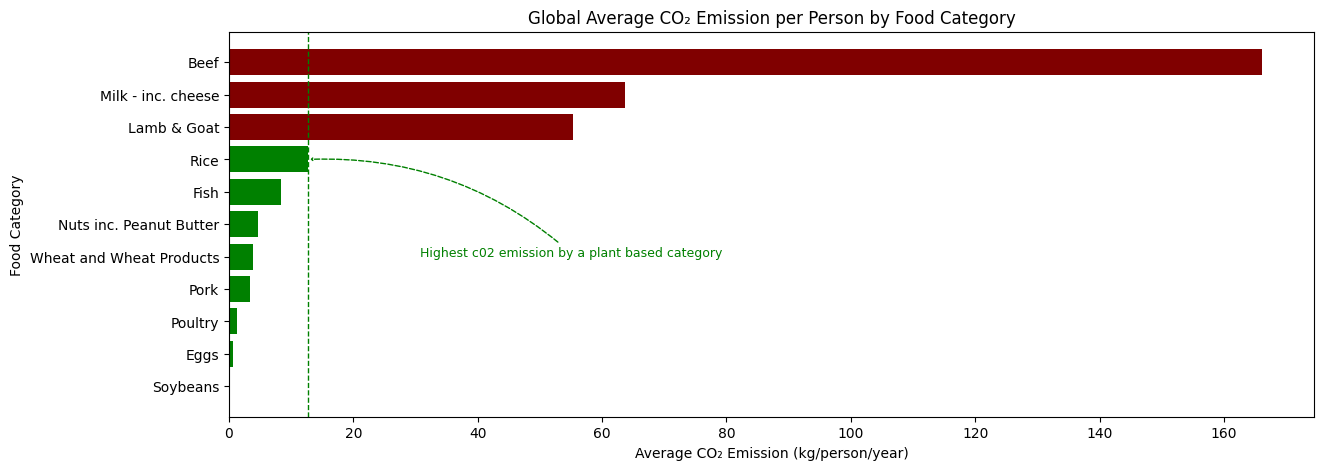

In [100]:
threshold = 13
colors = ['maroon' if v >= threshold else 'green' for v in avg_by_food_ea_sorted]

animal_based = ['Beef', 'Pork', 'Poultry', 'Lamb & Goat', 'Fish', 'Eggs','Milk - inc. cheese']
plant_based = [i for i in avg_by_food_ea_sorted.index if i not in animal_based]
rice_value = avg_by_food_ea_sorted.loc['Rice']


plt.figure(figsize=(14,5))
plt.barh(avg_by_food_ea_sorted.index, avg_by_food_ea_sorted.values, color=colors)

plt.axvline(rice_value, color='green', linestyle='--', linewidth=1)

plt.title("Global Average CO₂ Emission per Person by Food Category")
plt.ylabel("Food Category")
plt.xlabel("Average CO₂ Emission (kg/person/year)")

y_pos = avg_by_food_ea_sorted.index.get_loc('Rice')
y_pos = avg_by_food_ea_sorted.index.get_loc('Rice')

plt.annotate('Highest c02 emission by a plant based category',xy=(rice_value, y_pos),xytext=(rice_value + 18, y_pos - 3),textcoords='data',arrowprops=dict(
        arrowstyle='->,head_length=0.1,head_width=0.1',connectionstyle="arc3,rad=0.2",color='green',linestyle='--', linewidth=1),fontsize=9,color='green',
        fontweight='light')

plt.show()


Highlight the marked difference between consumption and emissions in certain food product of your choice

In [10]:
carbon['food_category'].unique()

array(['Pork', 'Poultry', 'Beef', 'Lamb & Goat', 'Fish', 'Eggs',
       'Milk - inc. cheese', 'Wheat and Wheat Products', 'Rice',
       'Soybeans', 'Nuts inc. Peanut Butter'], dtype=object)

In [11]:
carbon['country'].unique()

array(['Argentina', 'Australia', 'Albania', 'Iceland', 'New Zealand',
       'USA', 'Uruguay', 'Luxembourg', 'Brazil', 'Kazakhstan', 'Sweden',
       'Bermuda', 'Denmark', 'Finland', 'Ireland', 'Greece', 'France',
       'Canada', 'Norway', 'Hong Kong SAR. China', 'French Polynesia',
       'Israel', 'Switzerland', 'Netherlands', 'Kuwait', 'United Kingdom',
       'Austria', 'Oman', 'Italy', 'Bahamas', 'Portugal', 'Malta',
       'Armenia', 'Slovenia', 'Chile', 'Venezuela', 'Belgium', 'Germany',
       'Russia', 'Croatia', 'Belarus', 'Spain', 'Paraguay',
       'New Caledonia', 'South Africa', 'Barbados', 'Lithuania', 'Turkey',
       'Estonia', 'Mexico', 'Costa Rica', 'Bolivia', 'Ecuador', 'Panama',
       'Czech Republic', 'Romania', 'Colombia', 'Maldives', 'Cyprus',
       'Serbia', 'United Arab Emirates', 'Algeria', 'Ukraine', 'Pakistan',
       'Swaziland', 'Latvia', 'Bosnia and Herzegovina', 'Fiji',
       'South Korea', 'Poland', 'Saudi Arabia', 'Botswana', 'Macedonia',
       '

In [80]:
compare_foods = ["Beef", "Poultry"]
subset = carbon[carbon["food_category"].isin(['Beef', 'Poultry'])]

In [81]:
focus_foods = ['Pork', 'Poultry', 'Beef', 'Lamb & Goat', 'Fish']
carbon_focus = carbon[carbon['food_category'].isin(focus_foods)]

In [82]:
avg_focus = (carbon_focus.groupby('food_category')[['consumption', 'co2_emmission']].mean().reset_index())

In [83]:
avg_focus

,food_category,consumption,co2_emmission
0,Beef,12.123385,374.102000
1,Fish,17.287077,27.601692
2,Lamb & Goat,2.600154,91.056769
3,Pork,16.123692,57.070077
4,Poultry,21.219231,22.793538


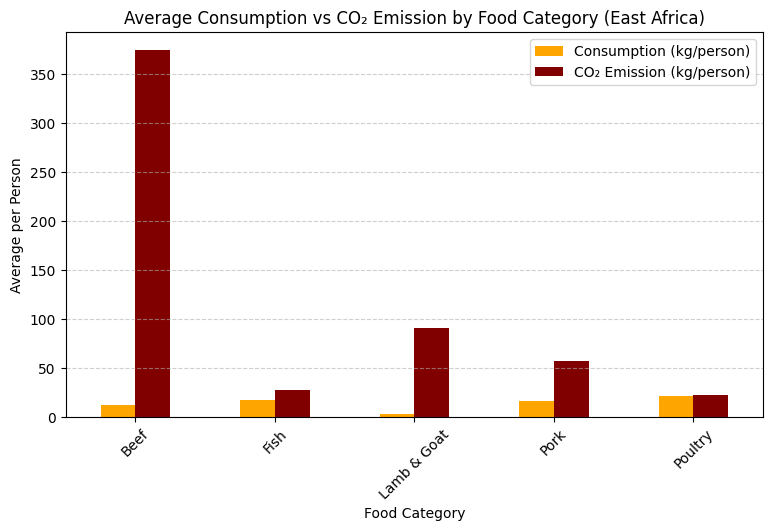

In [87]:
avg_focus.plot(x='food_category',y=['consumption', 'co2_emmission'],kind='bar',figsize=(9,5),color=['orange', 'maroon'])
plt.title('Average Consumption vs CO₂ Emission by Food Category (East Africa)')
plt.ylabel('Average per Person')
plt.xlabel('Food Category')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(['Consumption (kg/person)', 'CO₂ Emission (kg/person)'])
plt.show()

Beef has the highest emission compared to the consumption. The Co2 emission is 30 times the consumption
Poultry is the only food where the consumption and Co2 emission are equal


The food consumption of animal and non-animal products and the impact on carbon footprint. Use this image

In [101]:
avg_by_food = carbon.groupby("food_category")["co2_emmission"].mean()

In [102]:
avg_by_food

food_category
Beef                        374.102000
Eggs                          7.499615
Fish                         27.601692
Lamb & Goat                  91.056769
Milk - inc. cheese          179.153846
Nuts inc. Peanut Butter       7.323000
Pork                         57.070077
Poultry                      22.793538
Rice                         37.591615
Soybeans                      0.387308
Wheat and Wheat Products     13.644462
Name: co2_emmission, dtype: float64

In [103]:
avg_by_food_sorted = avg_by_food.sort_values()

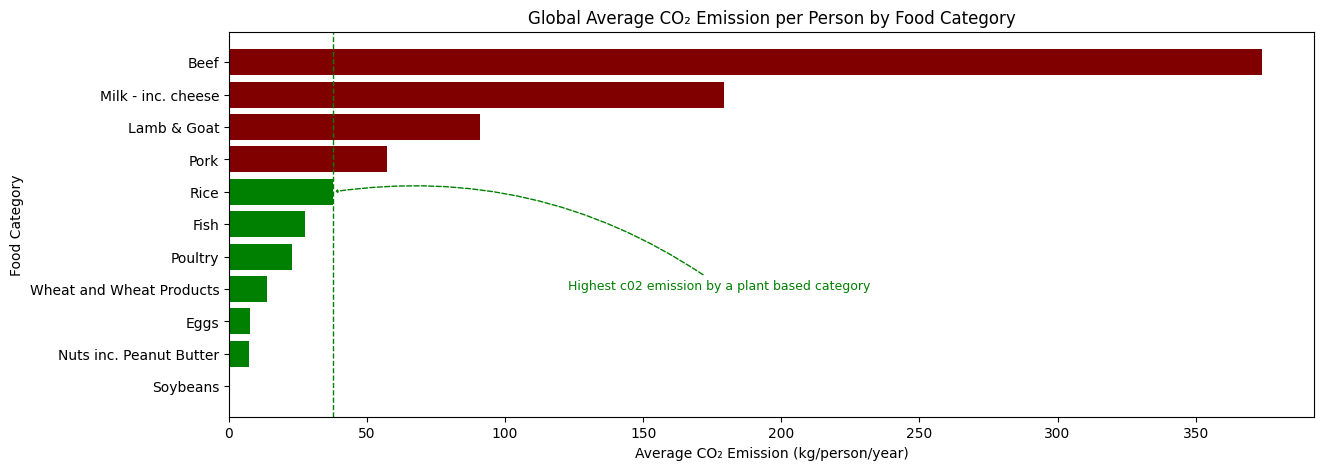

In [269]:
threshold = 38
colors = ['maroon' if v >= threshold else 'green' for v in avg_by_food_sorted]

animal_based = ['Beef', 'Pork', 'Poultry', 'Lamb & Goat', 'Fish', 'Eggs','Milk - inc. cheese']
plant_based = [i for i in avg_by_food_ea_sorted.index if i not in animal_based]
rice_value = avg_by_food_sorted.loc['Rice']


plt.figure(figsize=(14,5))
plt.barh(avg_by_food_sorted.index, avg_by_food_sorted.values, color=colors)

plt.axvline(rice_value, color='green', linestyle='--', linewidth=1)

plt.title("Global Average CO₂ Emission per Person by Food Category")
plt.ylabel("Food Category")
plt.xlabel("Average CO₂ Emission (kg/person/year)")

y_pos = avg_by_food_sorted.index.get_loc('Rice')

plt.annotate('Highest c02 emission by a plant based category',xy=(rice_value, y_pos),xytext=(rice_value + 85, y_pos -3),textcoords='data',arrowprops=dict(
        arrowstyle='->,head_length=0.1,head_width=0.1',connectionstyle="arc3,rad=0.2",color='green',linestyle='--', linewidth=1),fontsize=9,color='green',
        fontweight='light')

plt.show()

Beef's contribution to CO2 emissions (kg/person/year) - Map this.

In [17]:
beef = carbon[carbon["food_category"] == "Beef"]

In [18]:
beef_map = beef[['country', 'co2_emmission']].reset_index(drop=True)

In [271]:
fig = px.choropleth(beef_map,locations="country",locationmode="country names",color="co2_emmission",
                    color_continuous_scale="Reds",title="Beef Contribution to CO₂ Emissions per Person per Year (Global)",
                    labels={'co2_emmission': 'CO₂ (kg/person/year)'})

fig.update_layout(width=1100,height=500,geo=dict(showframe=False,showcoastlines=True,coastlinecolor="black",projection_type='natural earth',))

fig.show()

/var/folders/b7/64294z_j16d0t1nszkgct6_c0000gn/T/ipykernel_45578/4038563465.py:1: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



In [213]:
co2_emissions_order1 = carbon.groupby(['country','food_category'])['co2_emmission'].mean().sort_values(ascending=False)

In [217]:
co2_emissions_order1

country    food_category
Argentina  Beef             1712.00
Brazil     Beef             1211.17
USA        Beef             1118.29
Australia  Beef             1044.85
Bermuda    Beef             1022.94
                             ...   
Pakistan   Pork                0.00
           Soybeans            0.00
Ghana      Soybeans            0.00
Portugal   Soybeans            0.00
Nepal      Soybeans            0.00
Name: co2_emmission, Length: 1430, dtype: float64

In [183]:
co2_emissions_order = (carbon.groupby('food_category')['co2_emmission'].mean().sort_values(ascending=False).index)

In [184]:
co2_emissions_order

Index(['Beef', 'Milk - inc. cheese', 'Lamb & Goat', 'Pork', 'Rice', 'Fish',
       'Poultry', 'Wheat and Wheat Products', 'Eggs',
       'Nuts inc. Peanut Butter', 'Soybeans'],
      dtype='object', name='food_category')

In [275]:
unique_cats = len(co2_emissions_order)
colors = 'red','green', 'olive', 'blue','purple','yellow','brown','gray','gray','gray','gray'

A box plot and interpretation of the CO2 contributions of food levels. Use this image as inspiration

/var/folders/b7/64294z_j16d0t1nszkgct6_c0000gn/T/ipykernel_45578/1261594335.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




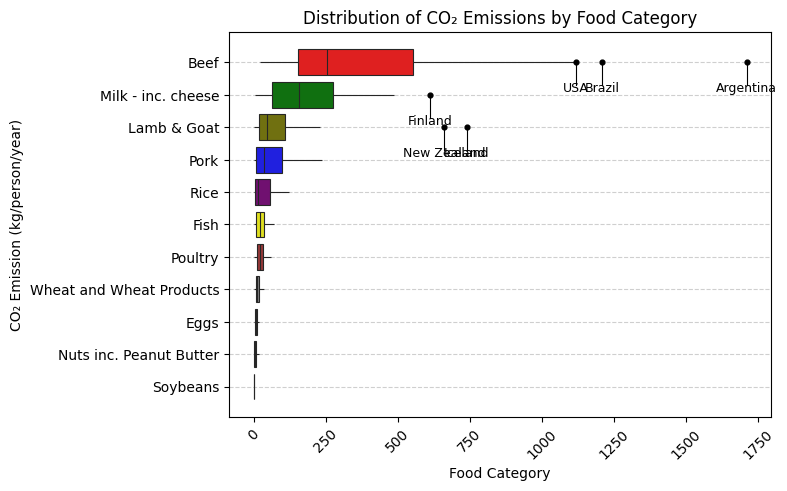

In [290]:
plt.figure(figsize=(7,5))
sns.boxplot(data=carbon, y='food_category', x='co2_emmission', orient ='h', order=co2_emissions_order,showcaps=False, showfliers=False,
            palette= sns.color_palette(colors[:len(co2_emissions_order)]),linewidth=0.8)

for category, group in carbon.groupby('food_category'):
    p98 = group['co2_emmission'].quantile(0.98)
    top_points = group[(group['co2_emmission'] > p98) & (group['co2_emmission'] > 600)]
    
    y_numeric = list(co2_emissions_order).index(category)
    
    plt.scatter(top_points['co2_emmission'], [y_numeric]*len(top_points), color='black', s=12, zorder=4)
    
    for x, country in zip(top_points['co2_emmission'], top_points['country']):
        y_label = y_numeric + 0.7
        plt.plot([x, x], [y_numeric, y_label], color='black', lw=0.8) 
        plt.text(x, y_label - 0.1, country, ha='center', va='top', fontsize=9, color='black')

plt.title("Distribution of CO₂ Emissions by Food Category")
plt.xlabel("Food Category")
plt.ylabel("CO₂ Emission (kg/person/year)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

Top 10 Countries with highest emissions. Choose the appropriate visual type. Get inspiration from this image

Use all your data to write a 500 words minimum of insights and the story behind your exploration.

Alternatively compile a set of slides with your insights.